# Évaluation rapide de checkpoints (MSE / CSI)
Entrées manuelles : chemins des données, liste de PKL (test), dossier de checkpoints, liste d’epochs.
Calculs : MSE (h, u, v) et CSI (pas de CSI_over) aux horizons 30 min / 3 h / 6 h / 12 h (1 / 6 / 12 / 24 pas).
Charge les poids via `modulus.launch.utils.load_checkpoint` en réutilisant les stats présentes dans le dossier de checkpoints.

In [1]:
import os, json, math
import torch, dgl
import numpy as np
import matplotlib.pyplot as plt
from typing import List
import sys

# Ajouter le repo au PYTHONPATH
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.append(ROOT)

from python.create_dgl_dataset import TelemacDataset, TelemacDatasetWithQ
from python.CustomMeshGraphNet import MeshGraphNet
from modulus.launch.utils import load_checkpoint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [2]:
# =====================
# Paramètres utilisateur (à adapter)
# =====================

# Graphe de base (DGL) et PKL de test
DATA_DIR = "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Multimesh_8_32.bin"
DYNAMIC_DIR = [ 
    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_1_peak_2600_Group_1_peak_2600_0_35-64_interpolated.pkl",
    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_2_peak_1000_Group_2_peak_1000_0_35-64_interpolated.pkl",
    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_2_peak_1200_Group_2_peak_1200_0_35-64_interpolated.pkl",
    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_2_peak_1600_Group_2_peak_1600_0_35-64_interpolated.pkl",
    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_4_peak_2000_Group_4_peak_2000_0_35-64_interpolated.pkl",
    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_1_peak_1200_Group_1_peak_1200_0_35-64_interpolated.pkl",
    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_1_peak_2400_Group_1_peak_2400_0_35-64_interpolated.pkl",
    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_3_peak_3400_Group_3_peak_3400_0_35-64_interpolated.pkl",
]

# Activer Q exogène
USE_Q_FEATURE = True
HYDRO_DIR = [
    '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_1_peak_2600.liq',
    '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_2_peak_1000.liq',
    '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_2_peak_1200.liq',
    '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_2_peak_1600.liq',
    '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_4_peak_2000.liq',
    '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_1_peak_1200.liq',
    '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_1_peak_2400.liq',
    '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_3_peak_3400.liq',
]
DT_SECONDS = 1800.0

# Méthodes à comparer (checkpoint fixe)
# - "epoch" pour un seul checkpoint
# - "epochs" pour en évaluer plusieurs d'un coup
METHODS = [
    {
        "name": "Experience8_multimesh_Q",
        "ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience8/Seed0/",
        "epoch": 900,
        "use_q_feature": True,
    },
]

# Paramètres modèle (cohérents avec l'entraînement)
NUM_EDGE_FEATURES = 3
NUM_OUTPUT_FEATURES = 3
MP_LAYERS = 10
DO_CONCAT_TRICK = True
NUM_PROCESSOR_CHECKPOINT_SEGMENTS = 0

# Horizons : CSI toutes les heures (pas de 30 min)
MAX_HOURS = 12
HOUR_IN_STEPS = max(1, int(round(3600.0 / DT_SECONDS)))
HORIZONS_STEPS = [h * HOUR_IN_STEPS for h in range(1, MAX_HOURS + 1)]

# Nombre de séquences à évaluer (prend les premières)
MAX_SEQUENCES = 205

# Seuil CSI
THRESHOLD_M = 0.05

# Export CSV
OUTPUT_CSV_PATH = "/work/m24046/m24046mrcr/paper/eval_fixed_checkpoints_hourly.csv"



In [3]:
import pickle as pkl
with open(DYNAMIC_DIR[0], 'rb') as f:
    data = pkl.load(f)
print(len(data))

30


In [4]:
# =====================
# Fonctions utilitaires
# =====================
def build_model(num_input_features):
    return MeshGraphNet(
        num_input_features,
        NUM_EDGE_FEATURES,
        NUM_OUTPUT_FEATURES,
        processor_size=MP_LAYERS,
        hidden_dim_processor=64,
        hidden_dim_node_encoder=64,
        hidden_dim_edge_encoder=64,
        hidden_dim_node_decoder=64,
        do_concat_trick=DO_CONCAT_TRICK,
        num_processor_checkpoint_segments=NUM_PROCESSOR_CHECKPOINT_SEGMENTS,
    )

def load_model_checkpoint(model, ckpt_dir, epoch):
    load_checkpoint(ckpt_dir, models=model, device=device, epoch=epoch)
    model.to(device)
    model.eval()
    return model

def build_dataset(
    sequence_length,
    ckpt_dir,
    use_q_feature,
    overlap=1,
    split="test",
    dynamic_dir=None,
    hydro_dir=None,
):
    dynamic_files = dynamic_dir if dynamic_dir is not None else DYNAMIC_DIR
    hydro_files = hydro_dir if hydro_dir is not None else HYDRO_DIR

    if use_q_feature:
        if len(hydro_files) == 0:
            raise ValueError("use_q_feature=True mais hydro_dir est vide.")
        if len(hydro_files) != len(dynamic_files):
            raise ValueError(
                f"hydro_dir ({len(hydro_files)}) et dynamic_dir ({len(dynamic_files)}) doivent avoir la même longueur."
            )
        ds = TelemacDatasetWithQ(
            name=f"eval_{split}",
            data_dir=DATA_DIR,
            dynamic_data_files=dynamic_files,
            hydro_data_files=hydro_files,
            split=split,
            ckpt_path=ckpt_dir,
            normalize=True,
            sequence_length=sequence_length,
            overlap=overlap,
            dt_seconds=DT_SECONDS,
        )
    else:
        ds = TelemacDataset(
            name=f"eval_{split}",
            data_dir=DATA_DIR,
            dynamic_data_files=dynamic_files,
            split=split,
            ckpt_path=ckpt_dir,
            normalize=True,
            sequence_length=sequence_length,
            overlap=overlap,
        )
    return ds

def _denorm(xn, mean, std):
    return xn * std + mean

def _renorm(x, mean, std):
    return (x - mean) / (std + 1e-12)

def csi_from_binary(pred_mask, gt_mask):
    tp = np.logical_and(pred_mask, gt_mask).sum()
    fp = np.logical_and(pred_mask, ~gt_mask).sum()
    fn = np.logical_and(~pred_mask, gt_mask).sum()
    denom = tp + fp + fn
    return float(tp / denom) if denom > 0 else math.nan

def evaluate_model(model, ds, horizons_steps, use_q_feature, max_sequences=10, threshold=0.05):
    stats = ds.node_stats
    dyn_start = ds.base_graph.ndata['static'].shape[1]
    dyn_len = 4 if use_q_feature else 3

    mx = torch.tensor([stats['h'].item(), stats['u'].item(), stats['v'].item()], device=device)
    sx = torch.tensor([stats['h_std'].item(), stats['u_std'].item(), stats['v_std'].item()], device=device)
    dy_mean = torch.tensor([stats['delta_h'].item(), stats['delta_u'].item(), stats['delta_v'].item()], device=device)
    dy_std  = torch.tensor([stats['delta_h_std'].item(), stats['delta_u_std'].item(), stats['delta_v_std'].item()], device=device)

    agg = {h: {"mse": [], "csi": []} for h in horizons_steps}
    nseq = min(max_sequences, len(ds))
    max_h = max(horizons_steps)

    for idx in range(nseq):
        graphs = ds[idx]
        if len(graphs) <= max_h:
            continue

        g = graphs[0].to(device)
        static_part = g.ndata['x'][:, :dyn_start]
        xn_t_full = g.ndata['x'][:, dyn_start:dyn_start+dyn_len]

        onehot = static_part[:, :4]
        q_mask = (onehot == torch.tensor([0,0,1,0], device=device)).all(dim=1)
        h_mask = (onehot == torch.tensor([0,1,0,0], device=device)).all(dim=1)

        for t in range(max_h):
            with torch.no_grad():
                y_pred_n = model(g.ndata['x'], g.edata['x'], g)

            xn_t = xn_t_full[:, :3]
            x_t = _denorm(xn_t, mx, sx)
            y_pred = _denorm(y_pred_n, dy_mean, dy_std)
            x_t1 = x_t + y_pred

            x_gt_full_n = graphs[t+1].ndata['x'][:, dyn_start:dyn_start+dyn_len].to(device)
            x_gt_n = x_gt_full_n[:, :3]
            x_gt = _denorm(x_gt_n, mx, sx)

            x_t1[q_mask] = x_gt[q_mask]
            x_t1[h_mask, 0:1] = x_gt[h_mask, 0:1]

            step = t+1
            if step in horizons_steps:
                mse = torch.mean((x_t1 - x_gt)**2, dim=0).detach().cpu().numpy()
                h_pred = x_t1[:,0].detach().cpu().numpy()
                h_gt = x_gt[:,0].detach().cpu().numpy()
                csi = csi_from_binary(h_pred >= threshold, h_gt >= threshold)
                agg[step]["mse"].append(mse)
                agg[step]["csi"].append(csi)

            xn_t1 = _renorm(x_t1, mx, sx)
            if use_q_feature:
                q_t1_n = x_gt_full_n[:, 3:4]
                xn_t_full = torch.cat([xn_t1, q_t1_n], dim=1)
            else:
                xn_t_full = xn_t1

            g = g.clone()
            g.ndata['x'] = torch.cat([static_part, xn_t_full], dim=1)

    summary = {}
    for h in horizons_steps:
        if len(agg[h]["mse"]) == 0:
            continue
        summary[h] = {
            "mse_mean": np.nanmean(np.stack(agg[h]["mse"], axis=0), axis=0).tolist(),
            "csi_mean": float(np.nanmean(agg[h]["csi"])),
        }
    return summary

def evaluate_single_checkpoint(
    ckpt_dir,
    epoch,
    horizons_steps,
    max_sequences=10,
    threshold=0.05,
    use_q_feature=USE_Q_FEATURE,
    dynamic_dir=None,
    hydro_dir=None,
):
    ds = build_dataset(
        sequence_length=max(horizons_steps)+1,
        overlap=1,
        split="test",
        ckpt_dir=ckpt_dir,
        use_q_feature=use_q_feature,
        dynamic_dir=dynamic_dir,
        hydro_dir=hydro_dir,
    )

    expected_input_features = ds.base_graph.ndata['static'].shape[1] + (4 if use_q_feature else 3)
    model = build_model(expected_input_features)
    load_model_checkpoint(model, ckpt_dir, epoch=epoch)

    return evaluate_model(
        model,
        ds,
        horizons_steps,
        use_q_feature=use_q_feature,
        max_sequences=max_sequences,
        threshold=threshold,
    )

def evaluate_fixed_methods(methods, horizons_steps, max_sequences=10, threshold=0.05):
    fixed_metrics = {}
    for method in methods:
        name = method["name"]
        ckpt_dir = method["ckpt_dir"]
        use_q_feature = method.get("use_q_feature", USE_Q_FEATURE)
        dynamic_dir = method.get("dynamic_dir", DYNAMIC_DIR)
        hydro_dir = method.get("hydro_dir", HYDRO_DIR)

        if "epochs" in method:
            epochs = list(method["epochs"])
        elif "epoch" in method:
            epochs = [method["epoch"]]
        else:
            raise ValueError(f"Méthode {name}: il faut fournir 'epoch' ou 'epochs'.")

        for epoch in epochs:
            run_name = f"{name}@{epoch}"
            summary = evaluate_single_checkpoint(
                ckpt_dir=ckpt_dir,
                epoch=epoch,
                horizons_steps=horizons_steps,
                max_sequences=max_sequences,
                threshold=threshold,
                use_q_feature=use_q_feature,
                dynamic_dir=dynamic_dir,
                hydro_dir=hydro_dir,
            )
            fixed_metrics[run_name] = {
                "method": name,
                "epoch": epoch,
                "ckpt_dir": ckpt_dir,
                "threshold_m": threshold,
                "summary": summary,
            }
    return fixed_metrics

def plot_hourly_csi(fixed_metrics, horizons_steps):
    if not fixed_metrics:
        print("Pas de résultats")
        return

    hours = [step * DT_SECONDS / 3600.0 for step in horizons_steps]
    plt.figure(figsize=(10, 5))

    for run_name, payload in fixed_metrics.items():
        summary = payload["summary"]
        csi_vals = [summary.get(step, {}).get("csi_mean", np.nan) for step in horizons_steps]
        plt.plot(hours, csi_vals, marker='o', label=run_name)

    plt.title(f"CSI vs horizon (seuil={THRESHOLD_M:.3f} m)")
    plt.xlabel("Horizon (heures)")
    plt.ylabel("CSI")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()



In [5]:
# =====================
# Lancement de l'éval (checkpoints fixes)
# =====================
fixed_metrics = evaluate_fixed_methods(
    METHODS,
    horizons_steps=HORIZONS_STEPS,
    max_sequences=MAX_SEQUENCES,
    threshold=THRESHOLD_M,
)
fixed_metrics



Loading normalization statistics...


[10:04:53 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience8/Seed0/MeshGraphNet.0.0.mdlus to device cuda
[10:04:54 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience8/Seed0/checkpoint.0.0.pt to device cuda
[10:04:57 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience8/Seed0/MeshGraphNet.0.100.mdlus to device cuda
[10:04:57 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience8/Seed0/checkpoint.0.100.pt to device cuda
[10:05:00 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience8/Seed0/MeshGraphNet.0.200.mdlus to device cuda
[10:05:00 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience8/Seed0/checkpoint.0.200.pt to device cuda
[10:05:03 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience8/Seed0/MeshGraphNet.0.300.mdlus to device cu

{0: {6: {'mse_mean': [0.12848412990570068,
    0.030775612220168114,
    0.009101083502173424],
   'csi_mean': 0.6964103413657083},
  12: {'mse_mean': [0.5798039436340332,
    0.1167195737361908,
    0.032780613750219345],
   'csi_mean': 0.5069552956653742},
  24: {'mse_mean': [0.27743908762931824,
    0.044861629605293274,
    0.01863236352801323],
   'csi_mean': 0.5207360475725181}},
 100: {6: {'mse_mean': [0.015173816122114658,
    0.004659049212932587,
    0.0020786237437278032],
   'csi_mean': 0.8549522982390909},
  12: {'mse_mean': [0.06620357185602188,
    0.016037356108427048,
    0.008431756868958473],
   'csi_mean': 0.7355194494390429},
  24: {'mse_mean': [0.0970941036939621,
    0.015028301626443863,
    0.007341555319726467],
   'csi_mean': 0.7020400331336538}},
 200: {6: {'mse_mean': [0.006084713619202375,
    0.0033388601150363684,
    0.00147595489397645],
   'csi_mean': 0.9127007839965423},
  12: {'mse_mean': [0.028034579008817673,
    0.011452989652752876,
    0.005583

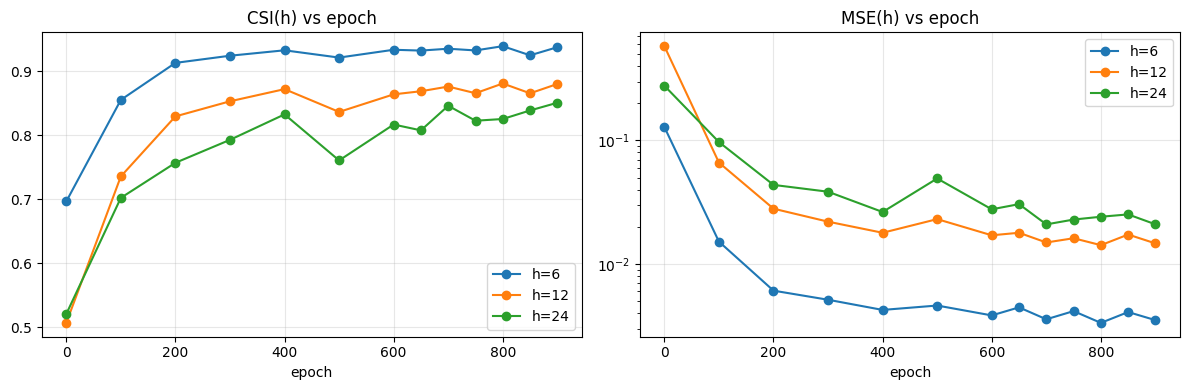

In [6]:
plot_hourly_csi(fixed_metrics, HORIZONS_STEPS)



In [7]:
import pandas as pd

rows = []
for run_name, payload in fixed_metrics.items():
    method = payload["method"]
    epoch = payload["epoch"]
    threshold = payload["threshold_m"]
    for h_step, vals in payload["summary"].items():
        mse_mean = vals.get("mse_mean", [np.nan, np.nan, np.nan])
        rows.append({
            "run_name": run_name,
            "method": method,
            "epoch": epoch,
            "horizon_steps": h_step,
            "horizon_hours": h_step * DT_SECONDS / 3600.0,
            "threshold_m": threshold,
            "mse_h": mse_mean[0],
            "mse_u": mse_mean[1],
            "mse_v": mse_mean[2],
            "csi": vals.get("csi_mean", np.nan),
        })

df = pd.DataFrame(rows).sort_values(["method", "epoch", "horizon_steps"]).reset_index(drop=True)

if OUTPUT_CSV_PATH:
    os.makedirs(os.path.dirname(OUTPUT_CSV_PATH), exist_ok=True)
    df.to_csv(OUTPUT_CSV_PATH, index=False)
    print(f"CSV sauvegardé: {OUTPUT_CSV_PATH}")

df



,epoch,horizon_steps,mse_h,mse_u,mse_v,csi
0,0,6,0.128484,0.030776,0.009101,0.696410
1,0,12,0.579804,0.116720,0.032781,0.506955
2,0,24,0.277439,0.044862,0.018632,0.520736
3,100,6,0.015174,0.004659,0.002079,0.854952
4,100,12,0.066204,0.016037,0.008432,0.735519
5,100,24,0.097094,0.015028,0.007342,0.702040
6,200,6,0.006085,0.003339,0.001476,0.912701
7,200,12,0.028035,0.011453,0.005583,0.829181
8,200,24,0.043677,0.011206,0.004558,0.756762
9,300,6,0.005136,0.002823,0.001327,0.923869
